In [ ]:
import copy
from itertools import pairwise

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import cluster
from tqdm.auto import tqdm

from emc.estimator.EMC import EMCLin
from emc.generator.markov import MarkovianSwitchingSystem
from emc.utils.compare import hellinger_distance
from emc.utils.plot import get_mpl_conf_path, set_size
from emc.utils.sparse import sparse_to_dense

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# synthetic data parameters
alphabet_cardinality = 4
mode_process_order = 1
subprocess_order = 1
number_of_subprocesses = 2
number_of_regimes = 2
regime_length_bounds = [1000,1200]
rng = np.random.default_rng(42)

# generate data

mss_ins = MarkovianSwitchingSystem(
    alphabet_cardinality=alphabet_cardinality,
    mode_process_order=mode_process_order,
    subprocess_order=subprocess_order,
    number_of_subprocesses=number_of_subprocesses,
    rng_or_seed=2
)
mss_ins.generate_subprocesses_with_min_dist(min_dist_threshold=0.25)
mss_ins.generate_subprocess_sequence(
    number_of_regimes=number_of_regimes,
    avoid_loops=True
)
symbol_seq = mss_ins.generate_symbol_sequence(
    regime_length_bounds=regime_length_bounds
)

mode_seq = mss_ins.subprocess_sequence
mode_seq_ext = np.repeat(mode_seq, mss_ins.regime_lengths)

cps = np.insert(0, 0, np.cumsum(mss_ins.regime_lengths))

In [4]:
emc1 = EMCLin(
    alpha=alphabet_cardinality,
    order=1,
    lambda_=[0.95, 0.95],
    beta=0.0,
    delta=[0.25, 0.25],
    eta=[0.3, 0.3],
    tau=40,
)

emc1_p_hist = []
for o in symbol_seq:
    emc1.process_symbol(o)
    emc1_p = copy.deepcopy(emc1.P)
    mat = sparse_to_dense(emc1_p, alpha=alphabet_cardinality, k=1)
    emc1_p_hist.append(mat)
emc1_p_hist = np.array(emc1_p_hist)

emc1_pmt = emc1.pred_mode_hist

emc1_st_hist = np.where(np.diff(emc1.stationarity_history) != 0)[0] + 1
emc1_st_hist = np.insert(emc1_st_hist, 0, 0)
emc1_st_hist = np.append(emc1_st_hist, len(emc1.stationarity_history) - 1)

In [5]:
emc2 = EMCLin(
    alpha=alphabet_cardinality,
    order=1,
    lambda_=[0.95, 0.95],
    beta=0.0,
    delta=[0.45, 0.45],
    eta=[0.3, 0.3],
    tau=40,
)
    
emc2_p_hist = []
for o in symbol_seq:
    emc2.process_symbol(o)
    emc2_p = copy.deepcopy(emc2.P)
    mat = sparse_to_dense(emc2_p, alpha=alphabet_cardinality, k=1)
    emc2_p_hist.append(mat)
emc2_p_hist = np.array(emc2_p_hist)

emc2_pmt = emc2.pred_mode_hist

emc2_st_hist = np.where(np.diff(emc2.stationarity_history) != 0)[0] + 1
emc2_st_hist = np.insert(emc2_st_hist, 0, 0)
emc2_st_hist = np.append(emc2_st_hist, len(emc2.stationarity_history) - 1)

Hellinger distance: [0.43073219 0.42215463 0.18020942 0.41748889]
0.431
0.422
0.180
0.417


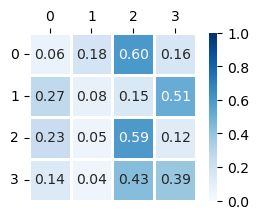

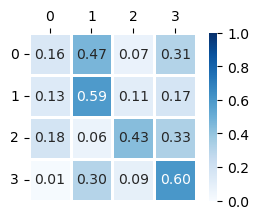

In [6]:
for mode_id in mss_ins.subprocesses:

    tm = mss_ins.subprocesses[mode_id].transition_matrix

    plt.style.use("default")
    # plt.style.use(get_mpl_conf_path("pub"))
    figsize = set_size(**{"width":"generic_paper", "aspect_ratio":1.5, "fraction":0.5})

    fig, ax = plt.subplots(figsize=figsize)

    hm1 = sns.heatmap(tm, annot=True, fmt=".2f", square=True, linewidth=0.75, cmap="Blues", vmin=0, vmax=1, cbar=True, ax=ax)

    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.xaxis.set_ticks_position('top')
    ax.grid(False)

    fig_name = f"impact_m{mode_id}_tm.pdf"
    fig.savefig(fig_name, bbox_inches="tight", pad_inches=0.1)

hd = hellinger_distance(mss_ins.subprocesses[0].transition_matrix, mss_ins.subprocesses[1].transition_matrix)
print(f"Hellinger distance: {hd}")
for hd_ in hd:
    print(f"{hd_:.3f}")

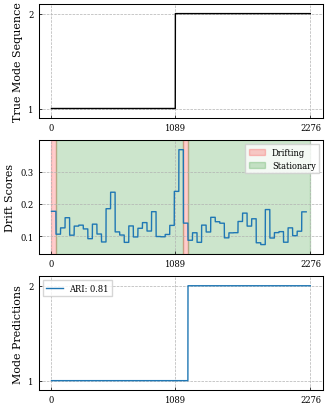

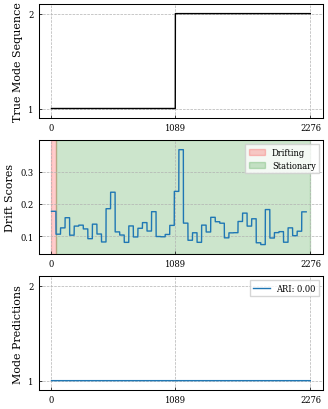

In [7]:
for emc_i, emc in enumerate([emc1, emc2]):

    plt.style.use("default")
    plt.style.use(get_mpl_conf_path("pub"))
    figsize = set_size(**{"width":"generic_paper", "aspect_ratio":0.8, "fraction":0.5})

    fig, axs = plt.subplots(3, 1, figsize=figsize)

    # true mode sequence
    sns.lineplot(x=np.arange(0, len(mode_seq_ext)), y=mode_seq_ext+1, color="black", ax=axs[0])
    axs[0].set_ylabel("True Mode Sequence")

    # emc drift scores
    emc_ds = np.repeat(emc.drift_scores, emc.tau)
    sns.lineplot(emc_ds, ax=axs[1])
    emc_st_hist = np.where(np.diff(emc.stationarity_history) != 0)[0] + 1
    emc_st_hist = np.insert(emc_st_hist, 0, 0)
    emc_st_hist = np.append(emc_st_hist, len(emc.stationarity_history) - 1)
    for i, (start, end) in enumerate(pairwise(emc_st_hist)):
        color = 'red' if i % 2 == 0 else 'green'
        axs[1].axvspan(start, end, color=color, alpha=0.2)
    handles = [
        mpatches.Patch(color='red', alpha=0.2, label='Drifting'),
        mpatches.Patch(color='green', alpha=0.2, label='Stationary')
    ]
    axs[1].legend(handles=handles)
    axs[1].set_ylabel("Drift Scores")

    # emc mode predictions
    emc_pmt = emc.pred_mode_hist
    emc_ari = cluster.adjusted_rand_score(mode_seq_ext, emc_pmt)
    sns.lineplot(emc_pmt, label=f"ARI: {emc_ari:.2f}", ax=axs[2])
    axs[2].set_ylabel("Mode Predictions")

    for ax in axs:
        ax.set_xticks(cps)
        ax.margins(x=0.05, y=0.1)
    
    for ax in [axs[0], axs[2]]:
        ax.set_yticks(np.unique(mode_seq)+1)
        ax.set_ylim(0.9, 2.1)

    # fig_name = f"impact_emc{emc_i+1}.pdf"
    # fig.savefig(fig_name, bbox_inches="tight", pad_inches=0.1)

    plt.show()

In [8]:
def plot_ari_impact(res, x_col, y_col, xlabel, ylabel, xticks=None):
    plt.style.use("default")
    plt.style.use(get_mpl_conf_path("pub"))
    figsize = set_size(**{"width":"generic_paper", "aspect_ratio":1.75, "fraction":0.5})

    fig, ax = plt.subplots(figsize=figsize)
    sns.lineplot(data=res, x=x_col, y=y_col, ax=ax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.margins(x=0.05, y=0.05)
    if xticks is not None:
        ax.set_xticks(xticks)

    return fig, ax

In [9]:
res_delta = []
deltas = np.arange(0.01, 1, 0.01)
for delta in tqdm(deltas):
    emc = EMCLin(
        alpha=4,
        order=1,
        lambda_=[0.95, 0.95],
        beta=0.0,
        delta=[delta, delta],
        eta=[0.3, 0.3],
        tau=40,
    )
    emc.process_sequence(symbol_seq)
    ari = cluster.adjusted_rand_score(emc.pred_mode_hist, mode_seq_ext)
    res_delta.append({"delta": delta, "ari": ari})

res_delta = pd.DataFrame(res_delta)

  0%|          | 0/99 [00:00<?, ?it/s]

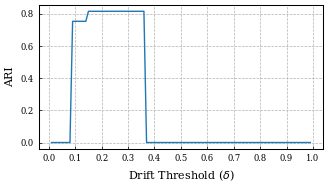

In [10]:
fig, ax = plot_ari_impact(res_delta, x_col="delta", y_col="ari", xlabel=r"Drift Threshold ($\delta$)", ylabel="ARI", xticks=np.arange(0, 1.01, 0.1))

# fig_name = "impact_ari_delta.pdf"
# fig.savefig(fig_name, bbox_inches="tight", pad_inches=0.1)
plt.show()

In [11]:
res_eta = []
etas = np.arange(0.01, 1, 0.01)
for eta in tqdm(etas):
    emc = EMCLin(
        alpha=4,
        order=1,
        lambda_=[0.95, 0.95],
        beta=0.0,
        delta=[0.25, 0.25],
        eta=[eta, eta],
        tau=40,
    )
    emc.process_sequence(symbol_seq)
    ari = cluster.adjusted_rand_score(emc.pred_mode_hist, mode_seq_ext)
    res_eta.append({"eta": eta, "ari": ari})

res_eta = pd.DataFrame(res_eta)

  0%|          | 0/99 [00:00<?, ?it/s]

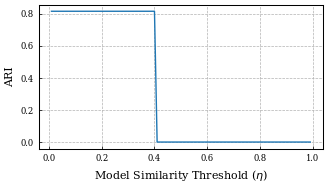

In [12]:
fig, ax = plot_ari_impact(res_eta, x_col="eta", y_col="ari", xlabel=r"Model Similarity Threshold ($\eta$)", ylabel="ARI")

# fig_name = "impact_ari_eta.pdf"
# fig.savefig(fig_name, bbox_inches="tight", pad_inches=0.1)
plt.show()

In [13]:
res_tau = []
taus = np.arange(10, 160, 10)
for tau in tqdm(taus):
    emc = EMCLin(
        alpha=4,
        order=1,
        lambda_=[0.95, 0.95],
        beta=0.0,
        delta=[0.25, 0.25],
        eta=[0.3, 0.3],
        tau=tau,
    )
    emc.process_sequence(symbol_seq)
    ari = cluster.adjusted_rand_score(emc.pred_mode_hist, mode_seq_ext)
    res_tau.append({"tau": tau, "ari": ari})

res_tau = pd.DataFrame(res_tau)

  0%|          | 0/15 [00:00<?, ?it/s]

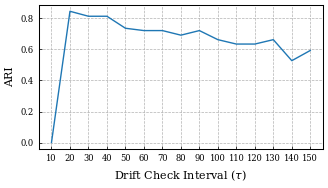

In [14]:
fig, ax = plot_ari_impact(res_tau, x_col="tau", y_col="ari", xlabel=r"Drift Check Interval ($\tau$)", ylabel="ARI", xticks=np.arange(10, 160, 10))

# fig_name = "impact_ari_tau.pdf"
# fig.savefig(fig_name, bbox_inches="tight", pad_inches=0.1)
plt.show()